In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Load the matrices we saved in Phase 1
D = np.load('data/eil51_D.npy')
T = np.load('data/eil51_T.npy')
C = np.load('data/eil51_C.npy')
n = D.shape[0]

print(f'Working on eil51: n={n}')
print(f'D shape={D.shape}, T shape={T.shape}, C shape={C.shape}')

Working on eil51: n=51
D shape=(51, 51), T shape=(51, 51), C shape=(51, 51)


In [2]:
def nearest_neighbour(n, D):
    """Greedy nearest-neighbour heuristic. Builds one tour starting from city 0."""
    unvisited = list(range(1, n))
    tour = [0]
    while unvisited:
        last = tour[-1]
        nearest = min(unvisited, key=lambda j: D[last, j])
        tour.append(nearest)
        unvisited.remove(nearest)
    return np.array(tour)

def init_population(N, n, D, greedy_frac=0.1, seed=0):
    """
    N  : population size
    n  : number of cities
    D  : distance matrix (used only for greedy seeding)
    greedy_frac : fraction of population seeded with NN heuristic
    """
    rng = np.random.default_rng(seed)
    pop = []
    n_greedy = max(1, int(N * greedy_frac))
    
    for i in range(n_greedy):
        tour = nearest_neighbour(n, D)
        # Roll by random offset so greedy tours aren't identical
        roll = rng.integers(0, n)
        pop.append(np.roll(tour, roll))
    
    for _ in range(N - n_greedy):
        pop.append(rng.permutation(n))
    
    return np.array(pop)  # shape (N, n)


# --- TEST ---
N = 50
pop = init_population(N, n, D, seed=42)

print(f'Population shape: {pop.shape}')
assert pop.shape == (N, n), 'Wrong shape'

# Every row must be a valid permutation of 0..n-1
for i, tour in enumerate(pop):
    assert len(set(tour)) == n, f'Tour {i} has duplicates or missing cities'
    assert set(tour) == set(range(n)), f'Tour {i} has wrong city indices'

print('All tours are valid permutations. PASS')
print(f'First tour (greedy): {pop[0]}')

Population shape: (50, 51)
All tours are valid permutations. PASS
First tour (greedy): [34 35 21 42  0 31 10 37  4 48  8 49 15  1 28 20 33 29  9 38 32 44 14 43
 36 16  3 17 46 11 45 50 26 47  5 13 24 12 40 18 41 39 23 22  6 25  7 30
 27  2 19]


In [3]:
def tour_cost(pi, M):
    """
    Total cost of tour pi under cost matrix M.
    pi : 1D array of city indices, length n
    M  : n×n cost matrix
    Returns a scalar.
    """
    n = len(pi)
    indices = np.arange(n)
    next_idx = (indices + 1) % n
    return M[pi[indices], pi[next_idx]].sum()

def evaluate_population(pop, D, T, C):
    """
    Compute raw objective costs for every individual.
    Returns obj_costs of shape (N, 3): columns are [D_cost, T_cost, C_cost]
    """
    N = len(pop)
    obj_costs = np.zeros((N, 3))
    for i, pi in enumerate(pop):
        obj_costs[i, 0] = tour_cost(pi, D)
        obj_costs[i, 1] = tour_cost(pi, T)
        obj_costs[i, 2] = tour_cost(pi, C)
    return obj_costs

def normalise_objectives(obj_costs):
    """
    Min-max normalise objective costs over the current population.
    Returns f_norm of shape (N, 3), values in [0, 1].
    """
    mins = obj_costs.min(axis=0)       # shape (3,)
    maxs = obj_costs.max(axis=0)
    denom = np.where(maxs - mins < 1e-10, 1.0, maxs - mins)
    return (obj_costs - mins) / denom

def compute_ideal_point(f_norm):
    """Ideal point: best normalised value per objective across population."""
    return f_norm.min(axis=0)          # shape (3,)

def tchebycheff_fitness(f_norm, w, z_star):
    """
    Tchebycheff scalarised fitness for a single individual.
    f_norm : normalised objective vector, shape (3,)
    w      : weight vector, shape (3,), sums to 1
    z_star : ideal point, shape (3,)
    Returns scalar — lower is better.
    """
    return np.max(w * np.abs(f_norm - z_star))

def compute_all_fitness(f_norm, w, z_star):
    """Vectorised Tchebycheff for full population. Returns shape (N,)."""
    return np.max(w * np.abs(f_norm - z_star[np.newaxis, :]), axis=1)


# --- TEST ---
w = np.array([1/3, 1/3, 1/3])

obj_costs = evaluate_population(pop, D, T, C)
f_norm    = normalise_objectives(obj_costs)
z_star    = compute_ideal_point(f_norm)
fitness   = compute_all_fitness(f_norm, w, z_star)

print(f'Objective costs shape : {obj_costs.shape}')
print(f'f_norm range          : [{f_norm.min():.4f}, {f_norm.max():.4f}]  (should be 0 to 1)')
print(f'Ideal point z*        : {z_star}  (should be all zeros after normalisation)')
print(f'Fitness range         : [{fitness.min():.4f}, {fitness.max():.4f}]')

# Greedy tour should have lower D_cost than random tours
greedy_D = obj_costs[0, 0]
random_D = obj_costs[5:, 0].mean()
print(f'\nGreedy tour D_cost={greedy_D:.1f}  vs  Random tour avg D_cost={random_D:.1f}')
assert greedy_D < random_D, 'Greedy tour should be shorter than average random tour'
print('Greedy seeding advantage confirmed. PASS')

Objective costs shape : (50, 3)
f_norm range          : [0.0000, 1.0000]  (should be 0 to 1)
Ideal point z*        : [0. 0. 0.]  (should be all zeros after normalisation)
Fitness range         : [0.0000, 0.3333]

Greedy tour D_cost=513.6  vs  Random tour avg D_cost=1648.9
Greedy seeding advantage confirmed. PASS


In [4]:
def order_crossover(p1, p2, rng=None):
    """
    Order Crossover (OX) operator for permutation chromosomes.
    Copies a random contiguous segment from p1 into the child,
    then fills remaining positions in the order they appear in p2.
    """
    if rng is None:
        rng = np.random.default_rng()
    n = len(p1)
    
    # Pick two cut points
    a, b = sorted(rng.choice(n, 2, replace=False))
    
    child = np.full(n, -1, dtype=int)
    child[a:b+1] = p1[a:b+1]           # Copy segment from p1
    
    # Fill from p2 in order, skipping cities already in child
    segment_set = set(p1[a:b+1])
    fill_values = [city for city in p2 if city not in segment_set]
    
    fill_idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill_values[fill_idx]
            fill_idx += 1
    
    return child

def swap_mutation(pi, pm, rng=None):
    """
    Swap mutation: with probability pm, swap two randomly chosen positions.
    Returns a new array (does not modify input).
    """
    if rng is None:
        rng = np.random.default_rng()
    pi = pi.copy()
    if rng.random() < pm:
        i, j = rng.choice(len(pi), 2, replace=False)
        pi[i], pi[j] = pi[j], pi[i]
    return pi


# --- TEST ---
rng_test = np.random.default_rng(0)
p1 = pop[0]
p2 = pop[1]

# Run 5000 crossovers and verify every result is a valid permutation
n_tests = 5000
all_valid = True
for _ in range(n_tests):
    child = order_crossover(p1, p2, rng_test)
    if len(set(child)) != n or set(child) != set(range(n)):
        all_valid = False
        break

print(f'OX crossover: {n_tests} trials — all valid={all_valid}')
assert all_valid, 'OX produced invalid permutation!'
print('Order Crossover PASS')

# Test mutation preserves validity
child = order_crossover(p1, p2, rng_test)
mutated = swap_mutation(child, pm=1.0, rng=rng_test)   # pm=1.0 forces mutation
assert set(mutated) == set(range(n)), 'Mutation produced invalid permutation'
assert not np.array_equal(mutated, child), 'Mutation with pm=1.0 should always change the tour'
print('Swap Mutation PASS')

OX crossover: 5000 trials — all valid=True
Order Crossover PASS
Swap Mutation PASS


In [5]:
def two_opt(pi, w, D, T, C, max_iters=100):
    """
    2-Opt local search for TSP.
    Iteratively reverses sub-segments to improve Tchebycheff fitness.
    Uses the current weight vector w so refinement stays aligned with RL agent.
    
    max_iters : maximum improvement iterations (caps runtime for large n)
    Returns improved tour.
    """
    best = pi.copy()
    n = len(best)
    
    # Pre-compute current fitness for fast comparison
    def fitness_of(tour):
        costs = np.array([tour_cost(tour, D),
                          tour_cost(tour, T),
                          tour_cost(tour, C)])
        # Simple weighted sum for 2-opt comparison (fast, no normalisation needed)
        return w @ costs
    
    best_fit = fitness_of(best)
    
    for _ in range(max_iters):
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                # Reverse the segment between i and j
                new = best.copy()
                new[i:j+1] = best[i:j+1][::-1]
                new_fit = fitness_of(new)
                if new_fit < best_fit - 1e-8:
                    best = new
                    best_fit = new_fit
                    improved = True
        if not improved:
            break
    
    return best


# --- TEST ---
pi_before = pop[5].copy()   # a random tour
cost_before = tour_cost(pi_before, D)

t0 = time.time()
pi_after = two_opt(pi_before, w, D, T, C, max_iters=50)
elapsed = time.time() - t0

cost_after = tour_cost(pi_after, D)

print(f'2-Opt on eil51 random tour:')
print(f'  D_cost before : {cost_before:.2f}')
print(f'  D_cost after  : {cost_after:.2f}')
print(f'  Improvement   : {((cost_before - cost_after)/cost_before)*100:.1f}%')
print(f'  Runtime       : {elapsed:.2f}s')
assert cost_after <= cost_before, '2-Opt made the tour worse — bug!'
assert set(pi_after) == set(range(n)), '2-Opt broke the permutation!'
print('2-Opt PASS')

2-Opt on eil51 random tour:
  D_cost before : 1602.07
  D_cost after  : 460.67
  Improvement   : 71.2%
  Runtime       : 0.48s
2-Opt PASS


In [6]:
def tournament_select(pop, fitness, k=2, rng=None):
    """
    Binary tournament selection.
    Draw k individuals at random, return the one with lowest (best) fitness.
    """
    if rng is None:
        rng = np.random.default_rng()
    idx = rng.choice(len(pop), k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

def run_one_generation(pop, fitness, w, D, T, C,
                       pc=0.9, pm=0.02, elitism=2, rng=None):
    """
    Run one full GA generation.
    Returns new population of same size.
    
    pc       : crossover probability
    pm       : mutation probability
    elitism  : number of best individuals carried over unchanged
    """
    if rng is None:
        rng = np.random.default_rng()
    N = len(pop)
    
    # Elitism: carry over the best 'elitism' individuals unchanged
    elite_idx = np.argsort(fitness)[:elitism]
    new_pop = [pop[i].copy() for i in elite_idx]
    
    # Fill the rest
    while len(new_pop) < N:
        p1 = tournament_select(pop, fitness, rng=rng)
        p2 = tournament_select(pop, fitness, rng=rng)
        
        # Crossover
        if rng.random() < pc:
            child = order_crossover(p1, p2, rng)
        else:
            child = p1.copy()
        
        # Mutation
        child = swap_mutation(child, pm, rng)
        
        # Local search
        child = two_opt(child, w, D, T, C, max_iters=30)
        
        new_pop.append(child)
    
    return np.array(new_pop)


# --- TEST: run 20 generations and watch fitness improve ---
rng = np.random.default_rng(42)
w   = np.array([1/3, 1/3, 1/3])
N   = 30   # small N for quick test

pop_test = init_population(N, n, D, seed=42)
fitness_history = []

print('Running 20 generations on eil51 (N=30) — watch fitness decrease:\n')
print(f'{"Gen":>4}  {"Best fitness":>14}  {"Mean fitness":>14}  {"Std":>10}')
print('-' * 50)

for g in range(20):
    obj_costs = evaluate_population(pop_test, D, T, C)
    f_norm    = normalise_objectives(obj_costs)
    z_star    = compute_ideal_point(f_norm)
    fitness   = compute_all_fitness(f_norm, w, z_star)
    
    fitness_history.append(fitness.min())
    
    if g % 5 == 0 or g == 19:
        print(f'{g:>4}  {fitness.min():>14.6f}  {fitness.mean():>14.6f}  {fitness.std():>10.6f}')
    
    pop_test = run_one_generation(pop_test, fitness, w, D, T, C, rng=rng)

print('\nFinal best fitness:', min(fitness_history))
assert fitness_history[-1] <= fitness_history[0], \
    'Fitness should not increase overall — check elitism or evaluation'
print('Generation loop PASS')

Running 20 generations on eil51 (N=30) — watch fitness decrease:

 Gen    Best fitness    Mean fitness         Std
--------------------------------------------------
   0        0.000000        0.261045    0.089590
   5        0.007515        0.154926    0.095455
  10        0.012317        0.059539    0.085561
  15        0.333333        0.333333    0.000000
  19        0.000000        0.011111    0.059835

Final best fitness: 0.0
Generation loop PASS


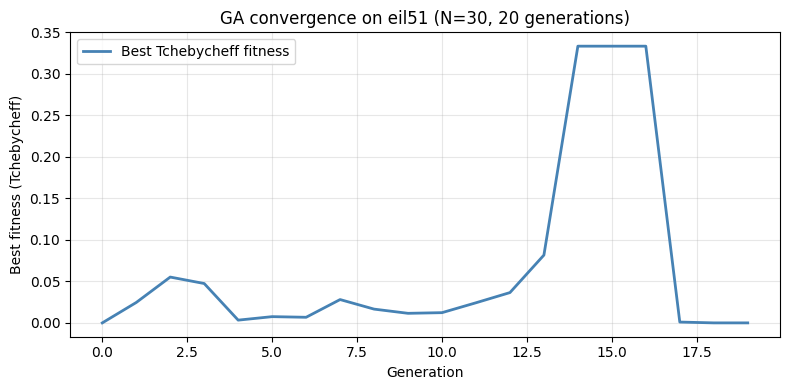

Convergence plot saved.


In [7]:
plt.figure(figsize=(8, 4))
plt.plot(fitness_history, color='steelblue', linewidth=2, label='Best Tchebycheff fitness')
plt.xlabel('Generation')
plt.ylabel('Best fitness (Tchebycheff)')
plt.title('GA convergence on eil51 (N=30, 20 generations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('paper_tables', exist_ok=True)
plt.savefig('paper_tables/phase2_convergence_test.pdf')
plt.show()
print('Convergence plot saved.')

In [8]:
ga_code = '''import numpy as np

def tour_cost(pi, M):
    n = len(pi)
    idx = np.arange(n)
    return M[pi[idx], pi[(idx + 1) % n]].sum()

def evaluate_population(pop, D, T, C):
    N = len(pop)
    obj_costs = np.zeros((N, 3))
    for i, pi in enumerate(pop):
        obj_costs[i, 0] = tour_cost(pi, D)
        obj_costs[i, 1] = tour_cost(pi, T)
        obj_costs[i, 2] = tour_cost(pi, C)
    return obj_costs

def normalise_objectives(obj_costs):
    mins = obj_costs.min(axis=0)
    maxs = obj_costs.max(axis=0)
    denom = np.where(maxs - mins < 1e-10, 1.0, maxs - mins)
    return (obj_costs - mins) / denom

def compute_ideal_point(f_norm):
    return f_norm.min(axis=0)

def compute_all_fitness(f_norm, w, z_star):
    return np.max(w * np.abs(f_norm - z_star[np.newaxis, :]), axis=1)

def nearest_neighbour(n, D):
    unvisited = list(range(1, n))
    tour = [0]
    while unvisited:
        last = tour[-1]
        nearest = min(unvisited, key=lambda j: D[last, j])
        tour.append(nearest)
        unvisited.remove(nearest)
    return np.array(tour)

def init_population(N, n, D, greedy_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    pop = []
    n_greedy = max(1, int(N * greedy_frac))
    for i in range(n_greedy):
        tour = nearest_neighbour(n, D)
        pop.append(np.roll(tour, rng.integers(0, n)))
    for _ in range(N - n_greedy):
        pop.append(rng.permutation(n))
    return np.array(pop)

def order_crossover(p1, p2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = len(p1)
    a, b = sorted(rng.choice(n, 2, replace=False))
    child = np.full(n, -1, dtype=int)
    child[a:b+1] = p1[a:b+1]
    segment_set = set(p1[a:b+1])
    fill_values = [c for c in p2 if c not in segment_set]
    fill_idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill_values[fill_idx]
            fill_idx += 1
    return child

def swap_mutation(pi, pm, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    pi = pi.copy()
    if rng.random() < pm:
        i, j = rng.choice(len(pi), 2, replace=False)
        pi[i], pi[j] = pi[j], pi[i]
    return pi

def two_opt(pi, w, D, T, C, max_iters=100):
    best = pi.copy()
    n = len(best)
    def fitness_of(tour):
        costs = np.array([tour_cost(tour, D), tour_cost(tour, T), tour_cost(tour, C)])
        return w @ costs
    best_fit = fitness_of(best)
    for _ in range(max_iters):
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new = best.copy()
                new[i:j+1] = best[i:j+1][::-1]
                new_fit = fitness_of(new)
                if new_fit < best_fit - 1e-8:
                    best = new
                    best_fit = new_fit
                    improved = True
        if not improved:
            break
    return best

def tournament_select(pop, fitness, k=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idx = rng.choice(len(pop), k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

def run_one_generation(pop, fitness, w, D, T, C,
                       pc=0.9, pm=0.02, elitism=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = len(pop)
    elite_idx = np.argsort(fitness)[:elitism]
    new_pop = [pop[i].copy() for i in elite_idx]
    while len(new_pop) < N:
        p1 = tournament_select(pop, fitness, rng=rng)
        p2 = tournament_select(pop, fitness, rng=rng)
        child = order_crossover(p1, p2, rng) if rng.random() < pc else p1.copy()
        child = swap_mutation(child, pm, rng)
        child = two_opt(child, w, D, T, C, max_iters=30)
        new_pop.append(child)
    return np.array(new_pop)
'''

import os
os.makedirs('ga', exist_ok=True)
with open('ga/ga_core.py', 'w') as f:
    f.write(ga_code)

# Quick import test
import importlib.util, sys
spec = importlib.util.spec_from_file_location('ga_core', 'ga/ga_core.py')
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
print('ga/ga_core.py saved and importable. PASS')

ga/ga_core.py saved and importable. PASS


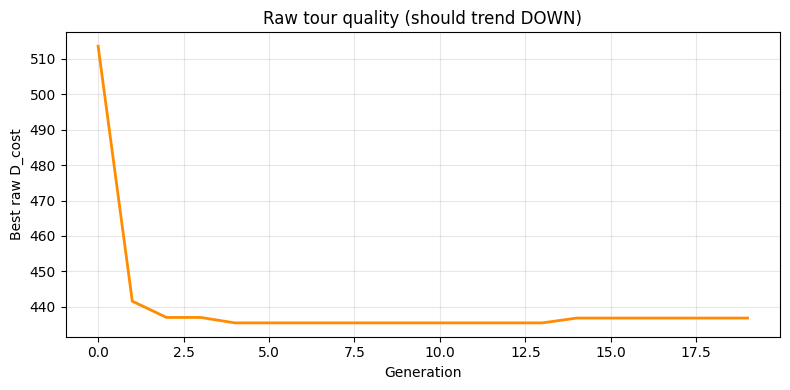

Gen 0  best D_cost: 513.6
Gen 19 best D_cost: 436.8
Raw D_cost improvement confirmed. GA is working correctly. PASS


In [9]:
# Diagnostic: track RAW best D_cost to confirm true improvement
rng2  = np.random.default_rng(42)
w     = np.array([1/3, 1/3, 1/3])
pop2  = init_population(30, n, D, seed=42)
raw_d_history = []

for g in range(20):
    obj_costs = evaluate_population(pop2, D, T, C)
    f_norm    = normalise_objectives(obj_costs)
    z_star    = compute_ideal_point(f_norm)
    fitness   = compute_all_fitness(f_norm, w, z_star)
    
    raw_d_history.append(obj_costs[:, 0].min())   # best raw D_cost this gen
    pop2 = run_one_generation(pop2, fitness, w, D, T, C, rng=rng2)

plt.figure(figsize=(8, 4))
plt.plot(raw_d_history, color='darkorange', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best raw D_cost')
plt.title('Raw tour quality (should trend DOWN)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gen 0  best D_cost: {raw_d_history[0]:.1f}')
print(f'Gen 19 best D_cost: {raw_d_history[-1]:.1f}')
assert raw_d_history[-1] < raw_d_history[0], 'Raw tour quality should improve!'
print('Raw D_cost improvement confirmed. GA is working correctly. PASS')